# CMU Simulation Model

Implements the Capital Markets Union (CMU) model following `v4 CMU_Model_Step_by_Step.md`.

**Country conventions:**
- `i` = origin country (investor / source of capital)
- `j` = destination country (receives capital)

This matches the data column suffixes: `_i` = origin, `_j` = destination.

**Data source:** `Data/Clean/Final-v4.csv`


In [11]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Step 0 — Assemble Data

In [18]:
df = pd.read_csv('Data/Clean/Final-v4.csv')
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Years:  {df["year"].min()} - {df["year"].max()}')

Loaded: 76,752 rows, 43 columns
Years:  2017 - 2024


In [19]:
# ── Country set: EU-27 + 4 outside options ────────────────────────────────
EU27 = [
    'AUT','BEL','BGR','HRV','CYP','CZE','DNK','EST','FIN','FRA','DEU','GRC',
    'HUN','IRL','ITA','LVA','LTU','LUX','MLT','NLD','POL','PRT','ROU','SVK',
    'SVN','ESP','SWE'
]
OUTSIDE = ['USA','GBR','CHE','NOR']
COUNTRIES = EU27 + OUTSIDE          # n = 31

# Eurozone members (used for euro_ij dummy in gravity & CMU shock)
EUROZONE = [
    'AUT','BEL','CYP','EST','FIN','FRA','DEU','GRC','IRL','ITA',
    'LVA','LTU','LUX','MLT','NLD','PRT','SVK','SVN','ESP'
]

n = len(COUNTRIES)
print(f'Country set: n = {n}  ({len(EU27)} EU + {len(OUTSIDE)} outside)')

Country set: n = 31  (27 EU + 4 outside)


In [20]:
# ── Filter to country set ─────────────────────────────────────────────────
df = df[df['iso3_i'].isin(COUNTRIES) & df['iso3_j'].isin(COUNTRIES)].copy()

# ── Choose base year: last year where both a_ij and k_i are non-null ──────
# For a_ij: last year where the *origin* (j) side has CPIS coverage
# For k_i:  last year where PWT capital stock is available for destinations
aij_last = df[df['a_ij'].notna()]['year'].max()
ki_last  = df[df['k_i'].notna()]['year'].max()
BASE_YEAR = min(aij_last, ki_last)
print(f'Last non-null year — a_ij: {aij_last},  k_i: {ki_last}')
print(f'Base year for simulation: {BASE_YEAR}')

Last non-null year — a_ij: 2024,  k_i: 2023
Base year for simulation: 2023


In [21]:
# ── Base-year cross section ───────────────────────────────────────────────
base = df[df['year'] == BASE_YEAR].copy()
print(f'Base-year rows: {len(base)}')
print(f'Unique iso3_i: {base["iso3_i"].nunique()},  iso3_j: {base["iso3_j"].nunique()}')

Base-year rows: 930
Unique iso3_i: 30,  iso3_j: 31


In [22]:
# Inspect if there are duplicates for last year by iso3_i and iso3_j
last_year_df = df[df['year'] == df['year'].max()]
duplicates = last_year_df[last_year_df.duplicated(subset=['iso3_i', 'iso3_j'], keep=False)]
print(f'Number of duplicate rows for last year: {len(duplicates)}')

Number of duplicate rows for last year: 0


In [23]:
# ── Forward-fill a_ij by bilateral pair, then take base-year cross-section ─
# Some country pairs have CPIS coverage in earlier years but not in BASE_YEAR.
# ffill within (iso3_i, iso3_j) carries the most recent known value forward.
df_aij = (df[df['iso3_i'].isin(COUNTRIES) & df['iso3_j'].isin(COUNTRIES)]
          .sort_values(['iso3_i', 'iso3_j', 'year'])
          .copy())
df_aij['a_ij_ff'] = (df_aij
                     .groupby(['iso3_i', 'iso3_j'])['a_ij']
                     .transform('ffill'))
base_ff = df_aij[df_aij['year'] == BASE_YEAR].copy()

pairs_added = (base_ff['a_ij_ff'].notna() & base_ff['a_ij'].isna()).sum()
print(f'Pairs gained from ffill: {pairs_added}')

# ── Build observed A matrix (n×n), a_ij = equity held by origin i in destination j ──
# Pivot: rows = origin i (investor), columns = destination j (receives capital)
A_data = base_ff.pivot(index='iso3_i', columns='iso3_j', values='a_ij_ff')

# Reindex to full country set (adds rows/cols for countries missing from CPIS)
A_data = A_data.reindex(index=COUNTRIES, columns=COUNTRIES)
A_data = A_data.fillna(0.0)

# ── Identify valid origins: present in CPIS with at least one outward holding ─
cpis_origins    = set(base_ff[base_ff['a_ij_ff'] > 0]['iso3_i'].unique())
VALID_ORIGINS   = [c for c in COUNTRIES if c in cpis_origins]
INVALID_ORIGINS = [c for c in COUNTRIES if c not in cpis_origins]

print(f'A matrix shape: {A_data.shape}')
print(f'Valid CPIS origins   ({len(VALID_ORIGINS)}): {VALID_ORIGINS}')
print(f'Destination-only / no outward CPIS data ({len(INVALID_ORIGINS)}): {INVALID_ORIGINS}')


Pairs gained from ffill: 4
A matrix shape: (31, 31)
Valid CPIS origins   (30): ['AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'SVK', 'SVN', 'ESP', 'SWE', 'USA', 'GBR', 'CHE', 'NOR']
Destination-only / no outward CPIS data (1): ['ROU']


In [ ]:
# ── Country-level macro variables for base year ───────────────────────────
# Pulled from the origin-side (_i) columns which have better country coverage.
# Each country's A, k, Y, L, alpha, M are the same physical quantities
# regardless of whether the country acts as origin or destination in a given row.
ctry_cols = ['iso3_i', 'M_i', 'k_i', 'Y_i', 'A_i', 'L_i', 'alpha_i', 'delta_i']
ctry = base.drop_duplicates('iso3_i').set_index('iso3_i')[ctry_cols[1:]]
ctry = ctry.reindex(COUNTRIES)

M     = ctry['M_i'].values       # stock market cap  (n,)
k     = ctry['k_i'].values       # capital stock
Y     = ctry['Y_i'].values       # real GDP
A     = ctry['A_i'].values       # TFP
L     = ctry['L_i'].values       # employment
alpha = ctry['alpha_i'].values   # capital share
delta = ctry['delta_i'].values   # depreciation

idx = {c: i for i, c in enumerate(COUNTRIES)}   # country → position index

print(ctry[['M_i', 'k_i', 'Y_i', 'alpha_i']].head(10).to_string())


                 M_i           k_i           Y_i   alpha_i
iso3_i                                                    
AUT     1.386335e+11  3.241278e+12  5.757506e+11  0.392000
BEL              NaN  3.976496e+12  6.782517e+11  0.413874
BGR     7.840630e+09  5.391208e+11  1.936551e+11  0.483489
HRV     2.535411e+10  7.555801e+11  1.450957e+11  0.387384
CYP     1.038013e+10  2.413204e+11  3.569566e+10  0.463422
CZE     3.466117e+10  2.851752e+12  4.838283e+11  0.488498
DNK              NaN  1.990346e+12  3.965176e+11  0.398817
EST              NaN  3.038233e+11  5.350984e+10  0.393288
FIN              NaN  1.846421e+12  2.928934e+11  0.417123
FRA              NaN  2.126019e+13  3.549413e+12  0.369021


In [25]:
# ── Diagonal: domestic holdings a_ii = M_i - foreign equity INTO i ────────
# Column i of A_arr = all origins' equity invested in destination i.
# a_ii = M_i - Σ_{k≠i} A[k, i]  (market cap minus what foreigners hold in i)
# Only filled for valid CPIS origins; invalid origins kept at zero.
# If reported foreign holdings exceed M_i (CPIS coverage issue), a_ii = 0.
# These countries are skipped in diagonal calibration (pi_home = 0 guard).
A_arr = A_data.values.copy()   # (n, n)  rows=origin i, cols=dest j

no_domestic = []
for i, ctry_i in enumerate(COUNTRIES):
    if ctry_i not in VALID_ORIGINS:
        A_arr[i, i] = 0.0
        continue
    foreign_into_i = A_arr[:, i].sum() - A_arr[i, i]   # col i ex-diagonal
    M_i = M[i]
    if np.isnan(M_i) or M_i <= 0:
        A_arr[i, i] = 0.0
        no_domestic.append(ctry_i)
    else:
        domestic = M_i - foreign_into_i
        if domestic <= 0:
            A_arr[i, i] = 0.0   # foreign holdings ≥ M_i; no observable domestic portion
            no_domestic.append(ctry_i)
        else:
            A_arr[i, i] = domestic

if no_domestic:
    print(f'Countries where foreign reported holdings ≥ M_i → a_ii = 0 ({len(no_domestic)}):')
    print('  ', no_domestic)

print('\nDiagonal (domestic holdings a_ii) — valid origins with a_ii > 0:')
diag_s = pd.Series(np.diag(A_arr), index=COUNTRIES)
print(diag_s[diag_s > 0].sort_values(ascending=False).head(10))


Countries where foreign reported holdings ≥ M_i → a_ii = 0 (16):
   ['BEL', 'DNK', 'EST', 'FIN', 'FRA', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'NLD', 'PRT', 'SVK', 'SWE', 'GBR', 'NOR']

Diagonal (domestic holdings a_ii) — valid origins with a_ii > 0:
USA    4.840501e+13
CHE    1.957265e+12
DEU    1.568010e+12
ESP    6.595088e+11
POL    1.868120e+11
GRC    5.706724e+10
HUN    2.250603e+10
AUT    2.236919e+10
HRV    2.235818e+10
CZE    1.731571e+10
dtype: float64


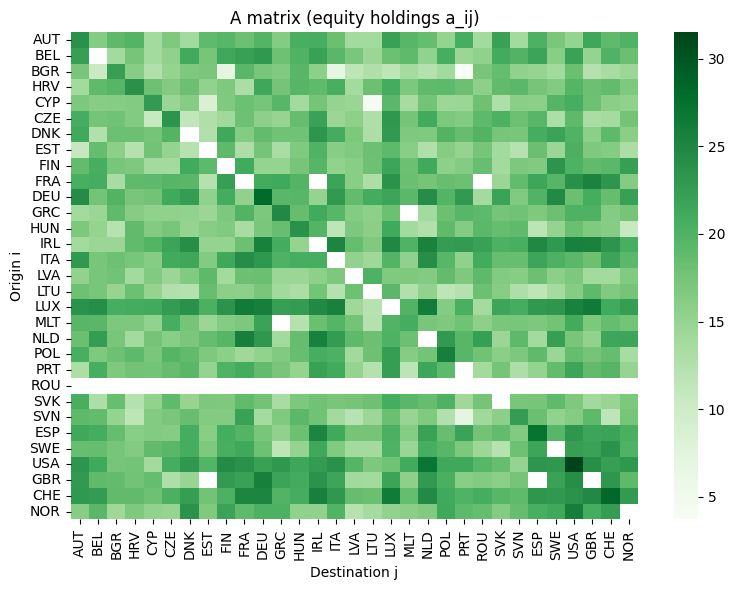

In [26]:
# heatmap plot the A matrix
# Set 0 to NaN for better color scaling (log(0) = -inf)
A_arr_log = np.log(A_arr)
A_arr_log[A_arr == 0] = np.nan

plt.figure(figsize=(8,6))
sns.heatmap(A_arr_log, xticklabels=COUNTRIES, yticklabels=COUNTRIES, cmap='Greens')
plt.title('A matrix (equity holdings a_ij)')
plt.xlabel('Destination j')
plt.ylabel('Origin i')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# ── Observed portfolio shares π_ij^data = a_ij / s_i ─────────────────────
# s_i = total outward holdings of origin i = row sums of A
# Invalid origins have s_i = 0 → their Pi_data row is NaN (excluded from calibration)
s = A_arr.sum(axis=1)   # (n,) row sums
s_for_pi = np.where(np.array([c in VALID_ORIGINS for c in COUNTRIES]), s, np.nan)
Pi_data = A_arr / s_for_pi[:, np.newaxis]   # row-normalize; invalid-origin rows → NaN

valid_rows = [i for i, c in enumerate(COUNTRIES) if c in VALID_ORIGINS]
print('Row sums for valid origins (should all be 1.0):')
print(np.round(Pi_data[valid_rows, :].sum(axis=1)[:8], 4))
print('\nHome bias π_ii (valid origins):')
print(pd.Series(np.diag(Pi_data), index=COUNTRIES)[VALID_ORIGINS]
      .sort_values(ascending=False).to_string())


Row sums for valid origins (should all be 1.0):
[1. 1. 1. 1. 1. 1. 1. 1.]

Home bias π_ii (valid origins):
USA    0.984859
POL    0.947990
GRC    0.922874
DEU    0.903738
HUN    0.871110
ESP    0.839669
BGR    0.828370
HRV    0.760473
CYP    0.759631
CHE    0.701572
AUT    0.573577
SVN    0.557057
CZE    0.482593
MLT    0.125215
IRL    0.000000
EST    0.000000
FIN    0.000000
FRA    0.000000
DNK    0.000000
BEL    0.000000
ITA    0.000000
LVA    0.000000
PRT    0.000000
NLD    0.000000
LTU    0.000000
LUX    0.000000
SWE    0.000000
SVK    0.000000
GBR    0.000000
NOR    0.000000


## Step 1 — Gravity Regression (PPML, all years, year FE)

In [28]:
# ── Prepare panel: all years, off-diagonal, country set ──────────────────
grav = df[
    df['iso3_i'].isin(COUNTRIES) &
    df['iso3_j'].isin(COUNTRIES) &
    (df['iso3_i'] != df['iso3_j'])   # exclude diagonal
].copy()

# Require positive a_ij for log transformation
grav = grav[grav['a_ij'] > 0].copy()

# Log transforms
grav['ln_a_ij']    = np.log(grav['a_ij'])
grav['ln_d_geo']   = np.log(grav['d_geo'])

# euro_ij = 1 if BOTH countries are in the Eurozone
grav['euro_ij'] = (grav['euro_i'] * grav['euro_j']).astype(float)

# Drop rows missing any regressor (use a_ij for PPML instead of ln_a_ij)
reg_cols = ['a_ij','ln_d_geo','d_cul','d_ling','euro_ij','iso3_i','iso3_j','year']
grav_reg = grav[reg_cols].dropna()
print(f'Regression sample: {len(grav_reg):,} observations across {grav_reg["year"].nunique()} years')

Regression sample: 320 observations across 5 years


In [ ]:
# ── PPML with destination FE, origin FE, year FE ──────────────────────
formula = (
    'a_ij ~ ln_d_geo + d_cul + d_ling + euro_ij '
    '+ C(iso3_i) + C(iso3_j) + C(year)'
)
ppml = smf.poisson(formula, data=grav_reg).fit(
    cov_type='cluster',
    cov_kwds={'groups': grav_reg['iso3_i'].astype(str) + '_' + grav_reg['iso3_j'].astype(str)}
)

beta_geo  = ppml.params['ln_d_geo']
beta_cul  = ppml.params['d_cul']
beta_ling = ppml.params['d_ling']
beta_euro = ppml.params['euro_ij']

# coefficient, p-value:.3f, t-stat in parentheses
print(ppml.summary().tables[0])
print(f'β_geo  (ln_d_geo):  {beta_geo:.3f}   p={ppml.pvalues["ln_d_geo"]:.3f}')
print(f'β_cul  (d_cul):     {beta_cul:.3f}   p={ppml.pvalues["d_cul"]:.3f}')
print(f'β_ling (d_ling):    {beta_ling:.3f}  p={ppml.pvalues["d_ling"]:.3f}')
print(f'β_euro (euro_ij):   {beta_euro:.3f}  p={ppml.pvalues["euro_ij"]:.3f}')

Optimization terminated successfully.
         Current function value: 4277853702.432723
         Iterations 12
                          Poisson Regression Results                          
Dep. Variable:                   a_ij   No. Observations:                  320
Model:                        Poisson   Df Residuals:                      296
Method:                           MLE   Df Model:                           23
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                  0.8108
Time:                        12:15:36   Log-Likelihood:            -1.3689e+12
converged:                       True   LL-Null:                   -7.2360e+12
Covariance Type:              cluster   LLR p-value:                     0.000
β_geo  (ln_d_geo):  -1.504   p=0.230
β_cul  (d_cul):     1.562   p=0.001
β_ling (d_ling):    7.535  p=0.005
β_euro (euro_ij):   -0.463  p=0.763


## Step 2 — Baseline Wedge Matrix

In [30]:
# ── Bilateral variables for base-year cross section ───────────────────────
# iso3_i = origin i, iso3_j = destination j (matches data convention)
bil_vars = base[['iso3_i', 'iso3_j', 'd_geo', 'd_cul', 'd_ling', 'euro_i', 'euro_j']].copy()
bil_vars['euro_ij'] = bil_vars['euro_i'] * bil_vars['euro_j']

# ── Off-diagonal wedges from gravity coefficients ─────────────────────────
# ln Δ_ij = -β_geo * ln(d_geo) - β_cul * d_cul - β_ling * d_ling - β_euro * euro_ij
# Negate betas: larger distance → larger wedge (Δ > 1 = friction)
# Delta[i, j] = friction faced by origin i investing in destination j

Delta_arr = np.ones((n, n))   # initialise (diagonal = 1 for now, calibrated below)

for _, row in bil_vars.iterrows():
    ci, cj = row['iso3_i'], row['iso3_j']   # ci = origin, cj = destination
    if ci == cj:
        continue
    if ci not in idx or cj not in idx:
        continue
    ii, jj = idx[ci], idx[cj]

    d_geo_val  = row['d_geo']
    d_cul_val  = row['d_cul']
    d_ling_val = row['d_ling']
    euro_val   = row['euro_ij']

    if pd.isna(d_geo_val) or d_geo_val <= 0:
        continue

    ln_delta = -beta_geo * np.log(d_geo_val)
    if not pd.isna(d_cul_val):
        ln_delta += -beta_cul  * d_cul_val
    if not pd.isna(d_ling_val):
        ln_delta += -beta_ling * d_ling_val
    if not pd.isna(euro_val):
        ln_delta += -beta_euro * euro_val

    Delta_arr[ii, jj] = np.exp(ln_delta)

# Pairs with no gravity data: keep wedge = 1 (no friction info)
print('Off-diagonal wedge stats (excluding diagonal):')
off = Delta_arr[~np.eye(n, dtype=bool)]
print(f'  min={off.min():.4f}, median={np.median(off):.4f}, max={off.max():.4f}')


Off-diagonal wedge stats (excluding diagonal):
  min=1.0000, median=1.0000, max=1.0000


In [31]:
# ── Returns R_j = MPK_j = α_j * Y_j / k_j, normalised to mean = 1 ────────
# These are destination j characteristics for the portfolio model.
# Pulled from _i columns (origin-side, better base-year coverage) — values are
# identical for the same country regardless of origin/destination role.
ctry_base = df[df['year'] == BASE_YEAR].drop_duplicates('iso3_i').set_index('iso3_i')
ctry_base = ctry_base.reindex(COUNTRIES)

R_vec = (ctry_base['alpha_i'] * ctry_base['Y_i'] / ctry_base['k_i']).values.astype(float)
M_vec = ctry_base['M_i'].values.astype(float)

# Fill missing with cross-country medians
R_vec = np.where(np.isnan(R_vec), np.nanmedian(R_vec), R_vec)
M_vec = np.where(np.isnan(M_vec) | (M_vec <= 0), np.nanmedian(M_vec[M_vec > 0]), M_vec)

# Normalise R so mean = 1
R_vec = R_vec / R_vec.mean()

print('Returns R_j (destination, normalised):')
print(pd.Series(R_vec, index=COUNTRIES).sort_values(ascending=False).head(10))


Returns R_j (destination, normalised):
IRL    2.182371
POL    1.920949
BGR    1.875753
MLT    1.779982
NOR    1.587471
USA    1.440899
LUX    1.097311
NLD    1.054261
LTU    1.053170
SVK    1.024257
dtype: float64


In [32]:
# ── Calibrate diagonal Δ_ii to match observed home bias ──────────────────
# π_ii = (R_i^η * M_i / Δ_ii) / Σ_ι (R_ι^η * M_ι / Δ_iι)
# Iterative update: Δ_ii ← Δ_ii * (π̂_ii / π_ii^data)
# Skipped for: invalid origins (NaN π_ii) and degenerate cases (π_ii = 0 or ≥ 1)
eta = 1.0

pi_home = np.diag(Pi_data)   # observed home bias π_ii; NaN for invalid origins

# Initialise: small wedge only for calibratable origins, 1.0 (neutral) otherwise
for i, ci in enumerate(COUNTRIES):
    if (ci in VALID_ORIGINS
            and not np.isnan(pi_home[i])
            and 0 < pi_home[i] < 0.9999):
        Delta_arr[i, i] = 0.01
    else:
        Delta_arr[i, i] = 1.0

RM = (R_vec ** eta) * M_vec   # destination attractiveness weights (n,)

MAX_ITER = 500
TOL      = 1e-4

for iteration in range(MAX_ITER):
    max_err = 0.0
    for i, ci in enumerate(COUNTRIES):
        if ci not in VALID_ORIGINS:
            continue
        if np.isnan(pi_home[i]) or pi_home[i] <= 0 or pi_home[i] >= 0.9999:
            continue
        # Row i of Delta: attractiveness of each destination j for origin i
        w = RM / Delta_arr[i, :]
        Z_i = w.sum()
        pi_hat_ii = w[i] / Z_i
        Delta_arr[i, i] *= pi_hat_ii / pi_home[i]
        max_err = max(max_err, abs(pi_hat_ii - pi_home[i]))
    if max_err < TOL:
        print(f'Converged in {iteration+1} iterations (max error = {max_err:.6f})')
        break
else:
    print(f'Did not fully converge after {MAX_ITER} iterations (max error = {max_err:.6f})')

Delta_baseline = Delta_arr.copy()

calibrated = [c for c in VALID_ORIGINS
              if not np.isnan(pi_home[COUNTRIES.index(c)])
              and 0 < pi_home[COUNTRIES.index(c)] < 0.9999]
print('\nCalibrated diagonal wedges (Δ_ii):')
print(pd.Series(np.diag(Delta_baseline), index=COUNTRIES)[calibrated]
      .sort_values(ascending=False).to_string())
skipped = [c for c in VALID_ORIGINS if c not in calibrated]
print(f'\nSkipped (π_ii = 0 or ≥ 1, Δ_ii = 1): {skipped}')


Did not fully converge after 500 iterations (max error = 0.000129)

Calibrated diagonal wedges (Δ_ii):
USA    0.184983
CHE    0.009319
DEU    0.002969
ESP    0.001377
AUT    0.001016
MLT    0.000839
CZE    0.000436
POL    0.000294
HRV    0.000084
SVN    0.000064
HUN    0.000063
GRC    0.000059
BGR    0.000040
CYP    0.000032

Skipped (π_ii = 0 or ≥ 1, Δ_ii = 1): ['BEL', 'DNK', 'EST', 'FIN', 'FRA', 'IRL', 'ITA', 'LVA', 'LTU', 'LUX', 'NLD', 'PRT', 'SVK', 'SWE', 'GBR', 'NOR']


## Step 4 — Baseline Portfolio Shares

In [33]:
def compute_portfolio(Delta, R, M, eta):
    """
    Compute n×n portfolio share matrix.
      Rows = origin i, columns = destination j.
      π_ij = (R_j^η * M_j / Δ_ij) / Σ_ι (R_ι^η * M_ι / Δ_iι)
    """
    RM = (R ** eta) * M                  # (n,) destination attractiveness weights
    W  = RM[np.newaxis, :] / Delta       # (n, n)  W[i,j] = RM_j / Δ_ij
    Z  = W.sum(axis=1)                   # (n,)    row sums Z_i
    Pi = W / Z[:, np.newaxis]            # (n, n)  row-normalised shares
    return Pi

Pi_baseline = compute_portfolio(Delta_baseline, R_vec, M_vec, eta)

# Validation: diagonal π_ii should match observed home bias for calibrated origins
pi_base_home = np.diag(Pi_baseline)
comparison = pd.DataFrame({
    'π_data':     np.diag(Pi_data),
    'π_baseline': pi_base_home,
    'diff':        pi_base_home - np.diag(Pi_data)
}, index=COUNTRIES)
print('Home bias: data vs. baseline (calibrated origins only)')
print(comparison.dropna(subset=['π_data']).sort_values('π_data', ascending=False).round(4).to_string())

# Off-diagonal correlation — valid origins only (their rows are non-NaN)
mask   = ~np.eye(n, dtype=bool)
valid_i = np.array([c in VALID_ORIGINS for c in COUNTRIES])
mask_valid = mask & valid_i[:, np.newaxis]   # valid-origin rows only
pd_vals = Pi_data[mask_valid]
pb_vals = Pi_baseline[mask_valid]
finite  = np.isfinite(pd_vals) & np.isfinite(pb_vals)
corr = np.corrcoef(pd_vals[finite], pb_vals[finite])[0, 1]
print(f'\nOff-diagonal correlation (data vs baseline, valid origins): {corr:.4f}')


Home bias: data vs. baseline (calibrated origins only)
     π_data  π_baseline    diff
USA  0.9849      0.9850  0.0001
POL  0.9480      0.9480 -0.0000
GRC  0.9229      0.9229  0.0000
DEU  0.9037      0.9037  0.0000
HUN  0.8711      0.8711  0.0000
ESP  0.8397      0.8397  0.0000
BGR  0.8284      0.8284  0.0000
HRV  0.7605      0.7605  0.0000
CYP  0.7596      0.7596  0.0000
CHE  0.7016      0.7016  0.0000
AUT  0.5736      0.5736  0.0000
SVN  0.5571      0.5571  0.0000
CZE  0.4826      0.4826 -0.0000
MLT  0.1252      0.1252  0.0000
IRL  0.0000      0.0015  0.0015
EST  0.0000      0.0005  0.0005
FIN  0.0000      0.0005  0.0005
FRA  0.0000      0.0005  0.0005
DNK  0.0000      0.0006  0.0006
BEL  0.0000      0.0005  0.0005
ITA  0.0000      0.0006  0.0006
LVA  0.0000      0.0004  0.0004
PRT  0.0000      0.0004  0.0004
NLD  0.0000      0.0007  0.0007
LTU  0.0000      0.0007  0.0007
LUX  0.0000      0.0008  0.0008
SWE  0.0000      0.0006  0.0006
SVK  0.0000      0.0007  0.0007
GBR  0.0000      

## Steps 5–6 — CMU Shock & Counterfactual Portfolios

In [34]:
# EU membership flags for the CMU shock
eu_flag = np.array([1 if c in EU27 else 0 for c in COUNTRIES])   # (n,)
# Intra-EU off-diagonal pair mask
eu_pair = np.outer(eu_flag, eu_flag) * (1 - np.eye(n))   # (n, n)

PHI_SCENARIOS = [0.25, 0.50, 0.75, 1.00]

results = {}   # keyed by phi

for phi in PHI_SCENARIOS:
    # Δ^CMU = Δ^baseline^(1-phi)  for intra-EU off-diagonal, else unchanged
    Delta_cmu = Delta_baseline.copy()
    Delta_cmu = np.where(eu_pair.astype(bool),
                         Delta_baseline ** (1 - phi),
                         Delta_baseline)

    Pi_cmu = compute_portfolio(Delta_cmu, R_vec, M_vec, eta)
    results[phi] = {'Delta_cmu': Delta_cmu, 'Pi_cmu': Pi_cmu}

print('CMU scenarios computed for φ =', PHI_SCENARIOS)

CMU scenarios computed for φ = [0.25, 0.5, 0.75, 1.0]


In [35]:
# ── Change in home bias ΔHomeBias_j = π_jj^CMU - π_jj^baseline ───────────
home_bias_table = pd.DataFrame({'π_baseline': np.diag(Pi_baseline)}, index=COUNTRIES)
for phi in PHI_SCENARIOS:
    Pi_cmu = results[phi]['Pi_cmu']
    home_bias_table[f'π_CMU(φ={phi})']  = np.diag(Pi_cmu)
    home_bias_table[f'Δπ(φ={phi})']     = np.diag(Pi_cmu) - np.diag(Pi_baseline)

print('Home bias change by φ (EU27 only):')
eu_mask = [c in EU27 for c in COUNTRIES]
print(home_bias_table.loc[eu_mask].round(4).to_string())

Home bias change by φ (EU27 only):
     π_baseline  π_CMU(φ=0.25)  Δπ(φ=0.25)  π_CMU(φ=0.5)  Δπ(φ=0.5)  π_CMU(φ=0.75)  Δπ(φ=0.75)  π_CMU(φ=1.0)  Δπ(φ=1.0)
AUT      0.5736         0.5736         0.0        0.5736        0.0         0.5736         0.0        0.5736        0.0
BEL      0.0005         0.0005         0.0        0.0005        0.0         0.0005         0.0        0.0005        0.0
BGR      0.8284         0.8284         0.0        0.8284        0.0         0.8284         0.0        0.8284        0.0
HRV      0.7605         0.7605         0.0        0.7605        0.0         0.7605         0.0        0.7605        0.0
CYP      0.7596         0.7596         0.0        0.7596        0.0         0.7596         0.0        0.7596        0.0
CZE      0.4826         0.4826         0.0        0.4826        0.0         0.4826         0.0        0.4826        0.0
DNK      0.0006         0.0006         0.0        0.0006        0.0         0.0006         0.0        0.0006        0.0
EST  

## Step 7 — Capital Reallocation

In [36]:
# s_i = total equity portfolio of origin i (held fixed across scenarios)
s_vec = A_arr.sum(axis=1)    # (n,) row sums

# k_j^baseline = Σ_i π_ij^baseline * s_i  (capital received by destination j)
# In matrix form: k = Π^T · s  (column j of Π dotted with s)
k_baseline = Pi_baseline.T @ s_vec   # (n,)

capital_table = pd.DataFrame({'k_baseline': k_baseline}, index=COUNTRIES)

for phi in PHI_SCENARIOS:
    Pi_cmu = results[phi]['Pi_cmu']
    k_cmu  = Pi_cmu.T @ s_vec
    capital_table[f'k_CMU(φ={phi})']  = k_cmu
    capital_table[f'Δk/k(φ={phi})']   = (k_cmu - k_baseline) / k_baseline
    results[phi]['k_cmu'] = k_cmu

# Conservation check: total capital must be preserved
print('Capital conservation check (CMU total / baseline total):')
for phi in PHI_SCENARIOS:
    ratio = results[phi]['k_cmu'].sum() / k_baseline.sum()
    print(f'  φ={phi}: {ratio:.8f}')

print('\nCapital change (% points) — all countries:')
delta_k_cols = [c for c in capital_table.columns if 'Δk/k' in c]
print((capital_table[delta_k_cols] * 100).round(3).to_string())


Capital conservation check (CMU total / baseline total):
  φ=0.25: 1.00000000
  φ=0.5: 1.00000000
  φ=0.75: 1.00000000
  φ=1.0: 1.00000000

Capital change (% points) — all countries:
     Δk/k(φ=0.25)  Δk/k(φ=0.5)  Δk/k(φ=0.75)  Δk/k(φ=1.0)
AUT           0.0          0.0           0.0          0.0
BEL           0.0          0.0           0.0          0.0
BGR           0.0          0.0           0.0          0.0
HRV           0.0          0.0           0.0          0.0
CYP           0.0          0.0           0.0          0.0
CZE           0.0          0.0           0.0          0.0
DNK           0.0          0.0           0.0          0.0
EST           0.0          0.0           0.0          0.0
FIN           0.0          0.0           0.0          0.0
FRA           0.0          0.0           0.0          0.0
DEU           0.0          0.0           0.0          0.0
GRC           0.0          0.0           0.0          0.0
HUN           0.0          0.0           0.0          0.0
IRL  

## Step 8 — Output & Productivity Effects

In [ ]:
# Production parameters for each destination country j
# y_j = A_j * k_j^α_j * L_j^(1-α_j)
# Pulled from ctry_base (_i columns) — same values regardless of origin/dest role
A_prod = ctry_base['A_i'].values.astype(float)
L_prod = ctry_base['L_i'].values.astype(float)
alp    = ctry_base['alpha_i'].values.astype(float)

# Fill missing with median
A_prod = np.where(np.isnan(A_prod), np.nanmedian(A_prod), A_prod)
L_prod = np.where(np.isnan(L_prod), np.nanmedian(L_prod), L_prod)
alp    = np.where(np.isnan(alp),    np.nanmedian(alp),    alp)

def cobb_douglas_output(A, k, L, alpha):
    """y_j = A_j * k_j^α_j * L_j^(1-α_j)"""
    return A * (k ** alpha) * (L ** (1 - alpha))

y_baseline = cobb_douglas_output(A_prod, k_baseline, L_prod, alp)

gdp_table = pd.DataFrame({'y_baseline': y_baseline}, index=COUNTRIES)
mpk_table = pd.DataFrame(index=COUNTRIES)
mpk_table['MPK_baseline'] = alp * y_baseline / k_baseline

for phi in PHI_SCENARIOS:
    k_cmu = results[phi]['k_cmu']
    y_cmu = cobb_douglas_output(A_prod, k_cmu, L_prod, alp)
    gdp_table[f'y_CMU(φ={phi})']   = y_cmu
    gdp_table[f'Δy/y(φ={phi})']    = (y_cmu - y_baseline) / y_baseline
    mpk_table[f'MPK_CMU(φ={phi})'] = alp * y_cmu / k_cmu
    results[phi]['y_cmu'] = y_cmu

print('GDP change (% points) — all countries:')
delta_y_cols = [c for c in gdp_table.columns if 'Δy/y' in c]
print((gdp_table[delta_y_cols] * 100).round(3).to_string())


In [ ]:
# ── Aggregate EU GDP effect ───────────────────────────────────────────────
eu_idx = [idx[c] for c in EU27 if c in idx]
Y_EU_base = y_baseline[eu_idx].sum()

print('Aggregate EU GDP gain (%):')
print(f'{"φ":>6}  {"ΔY_EU/Y_EU":>12}')
for phi in PHI_SCENARIOS:
    Y_EU_cmu = results[phi]['y_cmu'][eu_idx].sum()
    gain = (Y_EU_cmu - Y_EU_base) / Y_EU_base * 100
    print(f'{phi:>6.2f}  {gain:>12.4f}%')

In [ ]:
# ── MPK convergence ───────────────────────────────────────────────────────
MPK_base_eu = mpk_table.loc[EU27]['MPK_baseline'].dropna()

print('MPK dispersion (std dev across EU countries):')
print(f'{"φ":>6}  {"σ_MPK":>10}  {"% reduction":>12}')
sigma_base = MPK_base_eu.std()
print(f'{"base":>6}  {sigma_base:>10.6f}  {"—":>12}')
for phi in PHI_SCENARIOS:
    sigma_cmu = mpk_table.loc[EU27][f'MPK_CMU(φ={phi})'].dropna().std()
    reduction = (sigma_base - sigma_cmu) / sigma_base * 100
    print(f'{phi:>6.2f}  {sigma_cmu:>10.6f}  {reduction:>11.2f}%')

## Step 9 — Robustness Checks

In [ ]:
# ── Helper: run full model for a given eta and country set ────────────────
def run_model(Delta_baseline_in, R, M, s, A_prod, k_vec, L_prod, alp,
              Pi_data_in, countries, EU27_list, eta, phi_list, label=''):
    n_ = len(countries)
    eu_flag_ = np.array([1 if c in EU27_list else 0 for c in countries])
    eu_pair_ = np.outer(eu_flag_, eu_flag_) * (1 - np.eye(n_))
    eu_idx_  = [i for i, c in enumerate(countries) if c in EU27_list]

    # Re-calibrate diagonal for this eta (same guards as main calibration)
    D = Delta_baseline_in.copy()
    RM = (R ** eta) * M
    pi_home = np.diag(Pi_data_in)
    for i in range(n_):
        if not np.isnan(pi_home[i]) and 0 < pi_home[i] < 0.9999:
            D[i, i] = 0.01
        else:
            D[i, i] = 1.0
    for _ in range(500):
        max_err = 0.0
        for i in range(n_):
            if np.isnan(pi_home[i]) or pi_home[i] <= 0 or pi_home[i] >= 0.9999:
                continue
            w = RM / D[i, :]   # row i: attractiveness of each destination for origin i
            Z = w.sum()
            pi_hat = w[i] / Z
            D[i, i] *= pi_hat / pi_home[i]
            max_err = max(max_err, abs(pi_hat - pi_home[i]))
        if max_err < 1e-4:
            break

    Pi_base = compute_portfolio(D, R, M, eta)
    k_base  = Pi_base.T @ s          # k_j = Σ_i π_ij * s_i
    y_base  = cobb_douglas_output(A_prod, k_base, L_prod, alp)
    Y_EU_base_ = y_base[eu_idx_].sum()

    rows = []
    for phi in phi_list:
        D_cmu  = np.where(eu_pair_.astype(bool), D ** (1 - phi), D)
        Pi_cmu = compute_portfolio(D_cmu, R, M, eta)
        k_cmu  = Pi_cmu.T @ s
        y_cmu  = cobb_douglas_output(A_prod, k_cmu, L_prod, alp)
        Y_EU_cmu_ = y_cmu[eu_idx_].sum()
        home_bias_change = np.diag(Pi_cmu)[eu_idx_].mean() - np.diag(Pi_base)[eu_idx_].mean()
        rows.append({
            'label': label, 'eta': eta, 'phi': phi,
            'ΔY_EU/Y_EU (%)': (Y_EU_cmu_ - Y_EU_base_) / Y_EU_base_ * 100,
            'Avg ΔHomeBias (EU)': home_bias_change,
        })
    return pd.DataFrame(rows)


# Baseline off-diagonal wedge matrix (diagonals stripped — re-calibrated inside run_model)
D_offdiag = Delta_baseline.copy()
np.fill_diagonal(D_offdiag, 1.0)

rob_results = []

rob_results.append(run_model(
    D_offdiag, R_vec, M_vec, s_vec, A_prod, k_baseline, L_prod, alp,
    Pi_data, COUNTRIES, EU27, eta=1.0, phi_list=PHI_SCENARIOS, label='Baseline (η=1)'
))

print('Baseline robustness row computed.')


In [ ]:
# ── η = 0.5 ───────────────────────────────────────────────────────────────
rob_results.append(run_model(
    D_offdiag, R_vec, M_vec, s_vec, A_prod, k_baseline, L_prod, alp,
    Pi_data, COUNTRIES, EU27, eta=0.5, phi_list=PHI_SCENARIOS, label='η=0.5'
))

# ── η = 2.0 ───────────────────────────────────────────────────────────────
rob_results.append(run_model(
    D_offdiag, R_vec, M_vec, s_vec, A_prod, k_baseline, L_prod, alp,
    Pi_data, COUNTRIES, EU27, eta=2.0, phi_list=PHI_SCENARIOS, label='η=2.0'
))

print('η robustness done.')

In [ ]:
# ── Exclude LU, IE, NL (financial centres) ────────────────────────────────
EXCL = ['LUX', 'IRL', 'NLD']
countries_ex     = [c for c in COUNTRIES if c not in EXCL]
EU27_ex          = [c for c in EU27 if c not in EXCL]
valid_origins_ex = set(VALID_ORIGINS) - set(EXCL)
n_ex             = len(countries_ex)

# Rebuild A matrix for reduced country set
A_ex = A_arr[np.ix_([idx[c] for c in countries_ex], [idx[c] for c in countries_ex])].copy()

# Refill diagonal for reduced set (same VALID_ORIGINS guard)
for i, ci in enumerate(countries_ex):
    if ci not in valid_origins_ex:
        A_ex[i, i] = 0.0
        continue
    M_i = M_vec[idx[ci]]
    if M_i <= 0 or np.isnan(M_i):
        A_ex[i, i] = 0.0
        continue
    foreign_into_i = A_ex[:, i].sum() - A_ex[i, i]
    domestic = M_i - foreign_into_i
    A_ex[i, i] = max(domestic, 0.01 * M_i)

# Portfolio shares (row-normalised, invalid origins → NaN row)
s_ex = A_ex.sum(axis=1)
s_for_pi_ex = np.where(np.array([c in valid_origins_ex for c in countries_ex]), s_ex, np.nan)
Pi_data_ex  = A_ex / s_for_pi_ex[:, np.newaxis]

R_ex   = np.array([R_vec[idx[c]]      for c in countries_ex])
M_ex   = np.array([M_vec[idx[c]]      for c in countries_ex])
A_ex_p = np.array([A_prod[idx[c]]     for c in countries_ex])
L_ex   = np.array([L_prod[idx[c]]     for c in countries_ex])
alp_ex = np.array([alp[idx[c]]        for c in countries_ex])
k_ex   = np.array([k_baseline[idx[c]] for c in countries_ex])

# Rebuild off-diagonal wedge matrix for reduced set
D_ex = D_offdiag[np.ix_([idx[c] for c in countries_ex], [idx[c] for c in countries_ex])]

rob_results.append(run_model(
    D_ex, R_ex, M_ex, s_ex, A_ex_p, k_ex, L_ex, alp_ex,
    Pi_data_ex, countries_ex, EU27_ex, eta=1.0, phi_list=PHI_SCENARIOS,
    label='Excl. LUX/IRL/NLD'
))

print('Financial-centre exclusion robustness done.')


In [ ]:
# ── Robustness summary table ──────────────────────────────────────────────
rob_df = pd.concat(rob_results, ignore_index=True)
print('Robustness Summary:')
print(rob_df.round(4).to_string(index=False))